# HAM10000 / ISIC Dataset Inspection

This notebook is for **first inspection** of the HAM10000 skin-lesion dataset.

It checks:

- metadata columns
- missing values
- class distribution
- age distribution
- sex and localization distributions
- image availability
- duplicate lesions via `lesion_id`
- random image examples by diagnosis class

Expected common Kaggle structure:

```text
HAM10000_metadata.csv
HAM10000_images_part_1/
HAM10000_images_part_2/
```

Set `DATA_DIR` below to the folder where you unzipped the dataset.


In [2]:
from pathlib import Path
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Optional but useful display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# CHANGE THIS to your dataset folder.
# Example:
# DATA_DIR = Path("/Users/nikos/Downloads/skin-cancer-mnist-ham10000")
DATA_DIR = Path("/Users/nikos/Documents/Master/Thesis/Software/Multimodal_CP")
metadata_path = DATA_DIR / "HAM10000_metadata.csv"

print("DATA_DIR exists:", DATA_DIR.exists())
print("Metadata exists:", metadata_path.exists())

DATA_DIR exists: True
Metadata exists: True


## 1. Locate files

In [3]:
# Show top-level files/folders
if DATA_DIR.exists():
    for p in sorted(DATA_DIR.iterdir()):
        print(p.name)
else:
    print("DATA_DIR does not exist. Change DATA_DIR to the correct path.")

.DS_Store
.ipynb_checkpoints
HAM10000_images_part_1
HAM10000_images_part_2
HAM10000_metadata.csv
ham10000_inspection_notebook.ipynb
hmnist_28_28_L.csv
hmnist_28_28_RGB.csv
hmnist_8_8_L.csv
hmnist_8_8_RGB.csv


In [4]:
# Find metadata CSV automatically
csv_files = list(DATA_DIR.rglob("*.csv"))
csv_files

[PosixPath('/Users/nikos/Documents/Master/Thesis/Software/Multimodal_CP/hmnist_28_28_L.csv'),
 PosixPath('/Users/nikos/Documents/Master/Thesis/Software/Multimodal_CP/hmnist_28_28_RGB.csv'),
 PosixPath('/Users/nikos/Documents/Master/Thesis/Software/Multimodal_CP/hmnist_8_8_RGB.csv'),
 PosixPath('/Users/nikos/Documents/Master/Thesis/Software/Multimodal_CP/hmnist_8_8_L.csv'),
 PosixPath('/Users/nikos/Documents/Master/Thesis/Software/Multimodal_CP/HAM10000_metadata.csv')]

In [5]:
# Common HAM10000 metadata filename
metadata_candidates = [p for p in csv_files if "metadata" in p.name.lower()]

if metadata_candidates:
    metadata_path = metadata_candidates[0]
else:
    # fallback: use first CSV if only one exists
    metadata_path = csv_files[0] if csv_files else None

metadata_path

PosixPath('/Users/nikos/Documents/Master/Thesis/Software/Multimodal_CP/HAM10000_metadata.csv')

In [6]:
df = pd.read_csv(metadata_path)

print("Shape:", df.shape)
display(df.head())
display(df.tail())

Shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


,lesion_id,image_id,dx,dx_type,age,sex,localization
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face
10014,HAM_0003521,ISIC_0032258,mel,histo,70.0,female,back


## 2. Basic metadata inspection

In [7]:
print("Columns:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


In [8]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (100 * df.isna().mean()).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct.round(2)
})

display(missing_table)

,missing_count,missing_percent
age,57,0.57
image_id,0,0.00
lesion_id,0,0.00
dx,0,0.00
dx_type,0,0.00
sex,0,0.00
localization,0,0.00


In [9]:
# Basic statistics for numerical columns
display(df.describe(include="all"))

,lesion_id,image_id,dx,dx_type,age,sex,localization
count,10015,10015,10015,10015,9958.000000,10015,10015
unique,7470,10015,7,4,NaN,3,15
top,HAM_0003789,ISIC_0027419,nv,histo,NaN,male,back
freq,6,1,6705,5340,NaN,5406,2192
mean,NaN,NaN,NaN,NaN,51.863828,NaN,NaN
std,NaN,NaN,NaN,NaN,16.968614,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,40.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN


## 3. Diagnosis labels

In HAM10000, the main diagnosis column is usually `dx`.

Typical labels:

| Code | Meaning |
|---|---|
| nv | melanocytic nevi |
| mel | melanoma |
| bkl | benign keratosis-like lesions |
| bcc | basal cell carcinoma |
| akiec | actinic keratoses / intraepithelial carcinoma |
| vasc | vascular lesions |
| df | dermatofibroma |


In [10]:
label_col = "dx"

print(df[label_col].value_counts())
print("\nPercentages:")
print((100 * df[label_col].value_counts(normalize=True)).round(2))

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Percentages:
dx
nv       66.95
mel      11.11
bkl      10.97
bcc       5.13
akiec     3.27
vasc      1.42
df        1.15
Name: proportion, dtype: float64


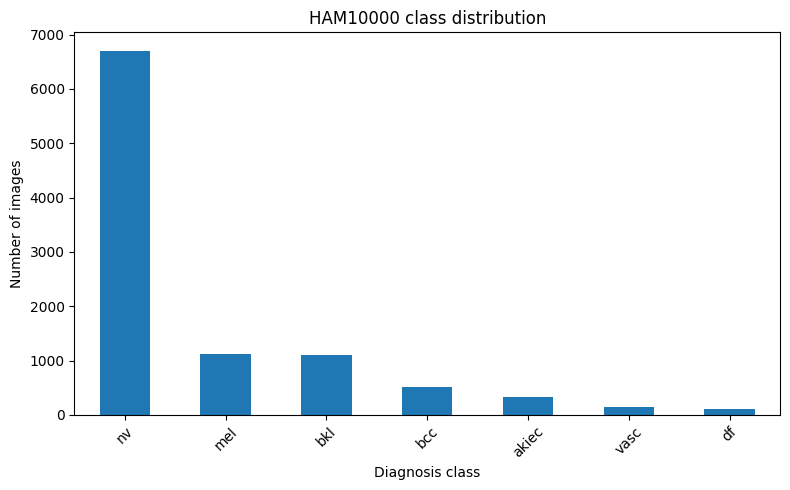

In [11]:
class_counts = df[label_col].value_counts()

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.xlabel("Diagnosis class")
plt.ylabel("Number of images")
plt.title("HAM10000 class distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Age, sex, and localization

For your multimodal multi-task idea, a clean setup is:

```text
Inputs:
    image + sex + localization

Outputs:
    classification: dx
    regression: age
```

Do **not** use age as input if age is the regression target.


count    9958.000000
mean       51.863828
std        16.968614
min         0.000000
25%        40.000000
50%        50.000000
75%        65.000000
max        85.000000
Name: age, dtype: float64


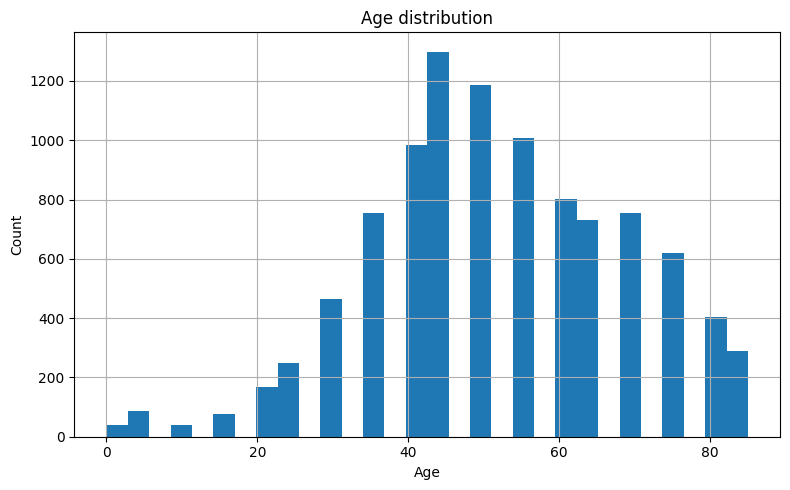

In [12]:
# Age distribution
if "age" in df.columns:
    print(df["age"].describe())

    plt.figure(figsize=(8, 5))
    df["age"].dropna().hist(bins=30)
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.title("Age distribution")
    plt.tight_layout()
    plt.show()
else:
    print("No age column found.")

sex
male       5406
female     4552
unknown      57
Name: count, dtype: int64

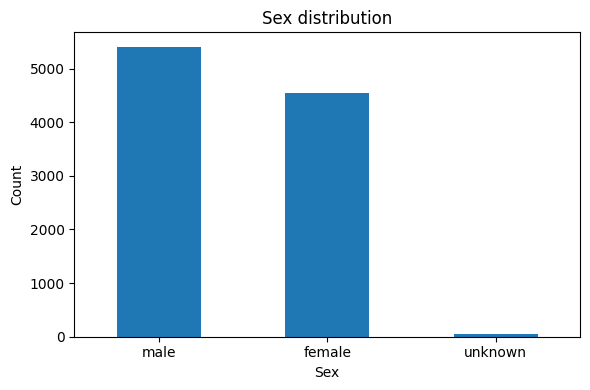

In [13]:
# Sex distribution
if "sex" in df.columns:
    display(df["sex"].value_counts(dropna=False))

    plt.figure(figsize=(6, 4))
    df["sex"].value_counts(dropna=False).plot(kind="bar")
    plt.xlabel("Sex")
    plt.ylabel("Count")
    plt.title("Sex distribution")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No sex column found.")

localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
face                745
chest               407
foot                319
unknown             234
neck                168
scalp               128
hand                 90
ear                  56
genital              48
acral                 7
Name: count, dtype: int64

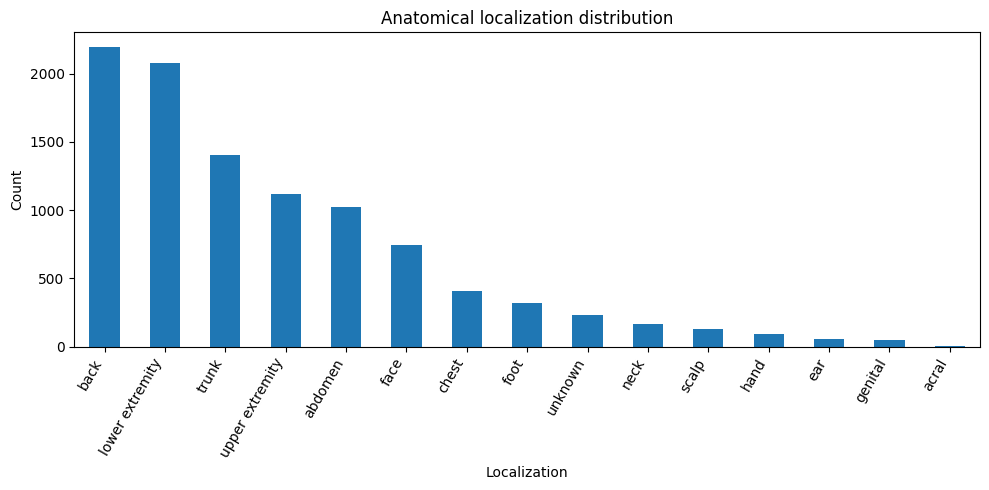

In [14]:
# Localization distribution
if "localization" in df.columns:
    display(df["localization"].value_counts(dropna=False))

    plt.figure(figsize=(10, 5))
    df["localization"].value_counts(dropna=False).plot(kind="bar")
    plt.xlabel("Localization")
    plt.ylabel("Count")
    plt.title("Anatomical localization distribution")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No localization column found.")

## 5. Find image paths

This creates a mapping:

```text
image_id -> actual image file path
```

It searches recursively inside `DATA_DIR`.


In [15]:
# Search for image files
image_extensions = [".jpg", ".jpeg", ".png"]
image_paths = []

for ext in image_extensions:
    image_paths.extend(DATA_DIR.rglob(f"*{ext}"))

print("Number of image files found:", len(image_paths))
print("First 5 image paths:")
for p in image_paths[:5]:
    print(p)

Number of image files found: 10015
First 5 image paths:
/Users/nikos/Documents/Master/Thesis/Software/Multimodal_CP/HAM10000_images_part_1/ISIC_0026784.jpg
/Users/nikos/Documents/Master/Thesis/Software/Multimodal_CP/HAM10000_images_part_1/ISIC_0028971.jpg
/Users/nikos/Documents/Master/Thesis/Software/Multimodal_CP/HAM10000_images_part_1/ISIC_0026948.jpg
/Users/nikos/Documents/Master/Thesis/Software/Multimodal_CP/HAM10000_images_part_1/ISIC_0026790.jpg
/Users/nikos/Documents/Master/Thesis/Software/Multimodal_CP/HAM10000_images_part_1/ISIC_0028965.jpg


In [16]:
# Create image_id -> path mapping.
# HAM10000 image filenames are usually like ISIC_0024306.jpg
image_path_map = {p.stem: p for p in image_paths}

df["image_path"] = df["image_id"].map(image_path_map)

print("Rows with missing image path:", df["image_path"].isna().sum())
display(df[["image_id", "image_path"]].head())

Rows with missing image path: 0


,image_id,image_path
0,ISIC_0027419,/Users/nikos/Documents/Master/Thesis/Software/...
1,ISIC_0025030,/Users/nikos/Documents/Master/Thesis/Software/...
2,ISIC_0026769,/Users/nikos/Documents/Master/Thesis/Software/...
3,ISIC_0025661,/Users/nikos/Documents/Master/Thesis/Software/...
4,ISIC_0031633,/Users/nikos/Documents/Master/Thesis/Software/...


In [17]:
# Keep only rows where image exists
df_available = df.dropna(subset=["image_path"]).copy()

print("Original rows:", len(df))
print("Rows with available images:", len(df_available))

Original rows: 10015
Rows with available images: 10015


## 6. Show random images

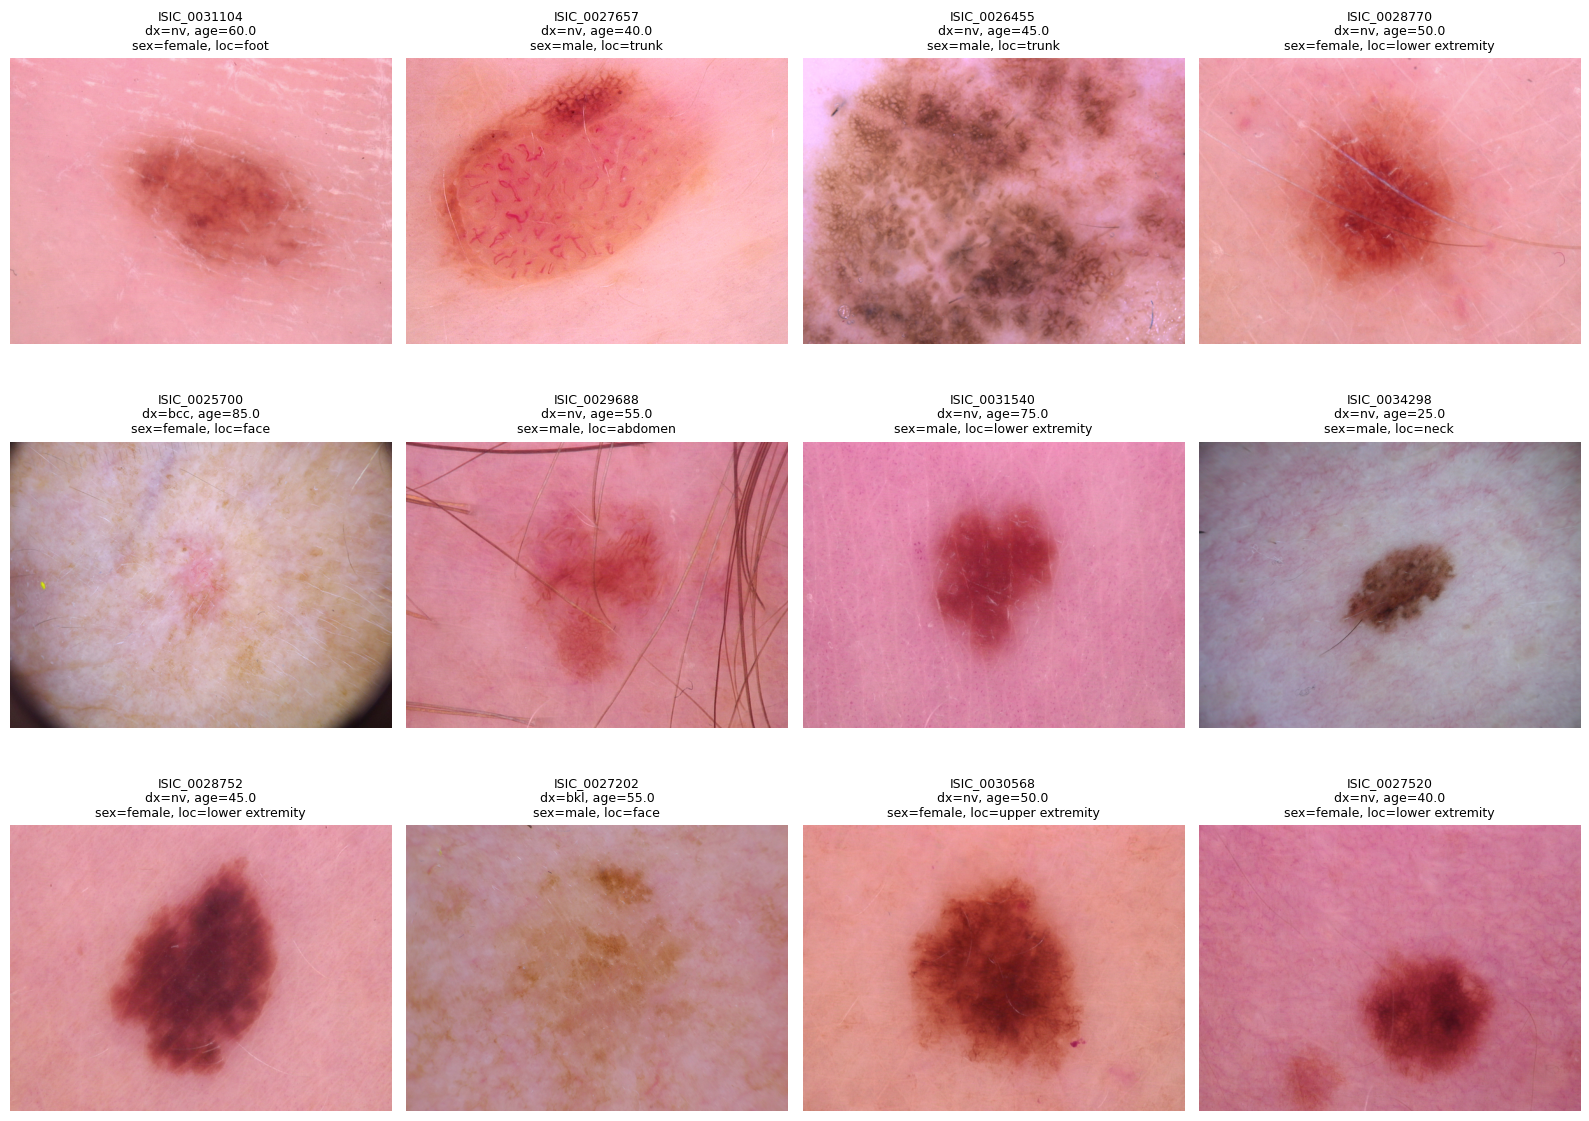

In [18]:
def show_random_images(dataframe, n=12, seed=42):
    sample = dataframe.sample(n=min(n, len(dataframe)), random_state=seed)

    cols = 4
    rows = int(np.ceil(len(sample) / cols))

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, (_, row) in enumerate(sample.iterrows(), 1):
        img = Image.open(row["image_path"])

        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")

        title = f'{row["image_id"]}\ndx={row["dx"]}'
        if "age" in row:
            title += f', age={row["age"]}'
        if "sex" in row:
            title += f'\nsex={row["sex"]}'
        if "localization" in row:
            title += f', loc={row["localization"]}'

        plt.title(title, fontsize=9)

    plt.tight_layout()
    plt.show()

show_random_images(df_available, n=12, seed=1)

## 7. Show examples from each diagnosis class

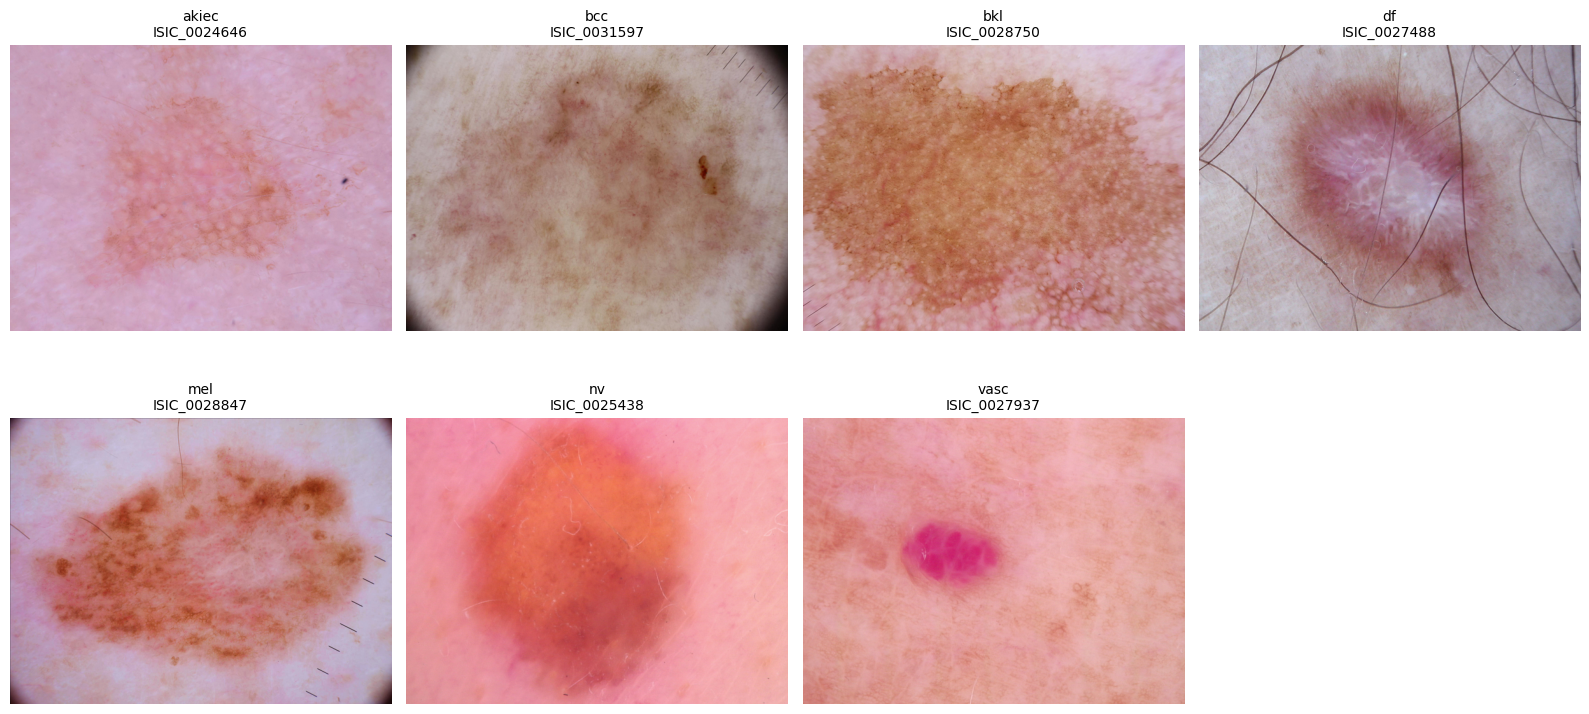

In [19]:
def show_one_per_class(dataframe, label_col="dx", seed=42):
    random.seed(seed)

    classes = sorted(dataframe[label_col].dropna().unique())
    n = len(classes)

    cols = 4
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, cls in enumerate(classes, 1):
        subset = dataframe[dataframe[label_col] == cls]
        row = subset.sample(1, random_state=seed).iloc[0]
        img = Image.open(row["image_path"])

        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{cls}\n{row['image_id']}", fontsize=10)

    plt.tight_layout()
    plt.show()

show_one_per_class(df_available)

## 8. Lesion-level duplicates and leakage check

HAM10000 can contain multiple images for the same lesion.

For proper ML evaluation, you should split by `lesion_id`, not by individual image, otherwise the same lesion may appear in train and test.


Number of unique lesions: 7470
Number of images: 10015

Images per lesion:


count    7470.000000
mean        1.340696
std         0.633970
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         6.000000
Name: count, dtype: float64


Lesions with more than one image: 1956


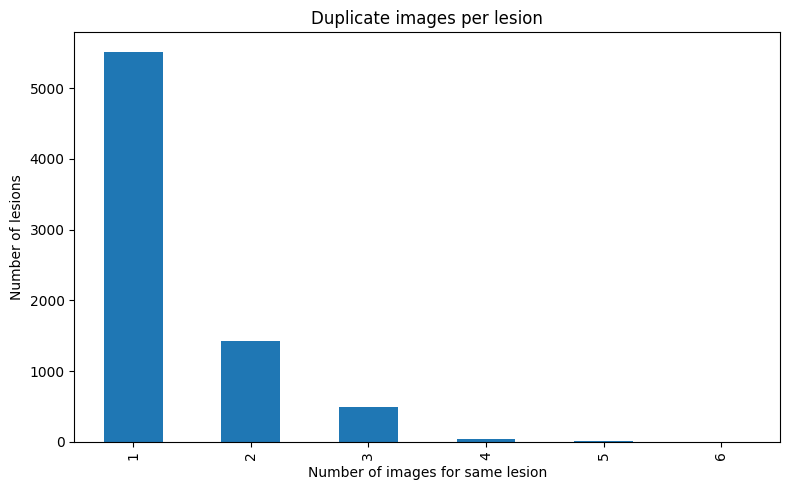

In [20]:
if "lesion_id" in df_available.columns:
    print("Number of unique lesions:", df_available["lesion_id"].nunique())
    print("Number of images:", len(df_available))

    lesion_counts = df_available["lesion_id"].value_counts()
    print("\nImages per lesion:")
    display(lesion_counts.describe())

    print("\nLesions with more than one image:", (lesion_counts > 1).sum())

    plt.figure(figsize=(8, 5))
    lesion_counts.value_counts().sort_index().plot(kind="bar")
    plt.xlabel("Number of images for same lesion")
    plt.ylabel("Number of lesions")
    plt.title("Duplicate images per lesion")
    plt.tight_layout()
    plt.show()
else:
    print("No lesion_id column found.")

## 9. Cross-tab checks

These help you see whether metadata is correlated with labels.


In [21]:
if "sex" in df_available.columns:
    display(pd.crosstab(df_available["dx"], df_available["sex"], normalize="index").round(3))

if "localization" in df_available.columns:
    display(pd.crosstab(df_available["dx"], df_available["localization"], normalize="index").round(3))

sex,female,male,unknown
dx,,,
akiec,0.324,0.676,0.000
bcc,0.383,0.617,0.000
bkl,0.421,0.570,0.009
df,0.452,0.548,0.000
mel,0.381,0.619,0.000
nv,0.483,0.510,0.007
vasc,0.514,0.486,0.000


localization,abdomen,acral,back,chest,ear,face,foot,genital,hand,lower extremity,neck,scalp,trunk,unknown,upper extremity
dx,,,,,,,,,,,,,,,
akiec,0.015,0.000,0.089,0.037,0.009,0.346,0.000,0.000,0.040,0.199,0.031,0.043,0.003,0.000,0.190
bcc,0.035,0.000,0.362,0.091,0.000,0.196,0.008,0.000,0.004,0.113,0.027,0.037,0.021,0.010,0.095
bkl,0.038,0.000,0.184,0.067,0.005,0.290,0.001,0.002,0.013,0.158,0.028,0.031,0.066,0.021,0.095
df,0.035,0.000,0.017,0.000,0.000,0.000,0.017,0.009,0.000,0.713,0.000,0.000,0.000,0.000,0.209
mel,0.059,0.000,0.291,0.061,0.015,0.093,0.025,0.000,0.001,0.173,0.026,0.013,0.042,0.009,0.191
nv,0.128,0.001,0.213,0.030,0.004,0.015,0.042,0.007,0.008,0.221,0.012,0.007,0.185,0.029,0.098
vasc,0.190,0.000,0.155,0.042,0.000,0.056,0.000,0.000,0.035,0.190,0.021,0.014,0.218,0.000,0.077


,count,mean,std,min,25%,50%,75%,max
dx,,,,,,,,
akiec,327.0,66.529052,11.476232,30.0,60.0,70.0,75.0,85.0
bcc,514.0,66.828794,13.656959,20.0,60.0,70.0,75.0,85.0
bkl,1089.0,64.283747,14.120715,0.0,55.0,65.0,75.0,85.0
df,115.0,53.043478,13.551326,25.0,45.0,50.0,65.0,80.0
mel,1111.0,60.679568,15.189847,5.0,50.0,60.0,70.0,85.0
nv,6660.0,46.477477,15.183275,0.0,35.0,45.0,55.0,85.0
vasc,142.0,51.373239,21.644651,0.0,40.0,55.0,70.0,85.0


<Figure size 800x500 with 0 Axes>

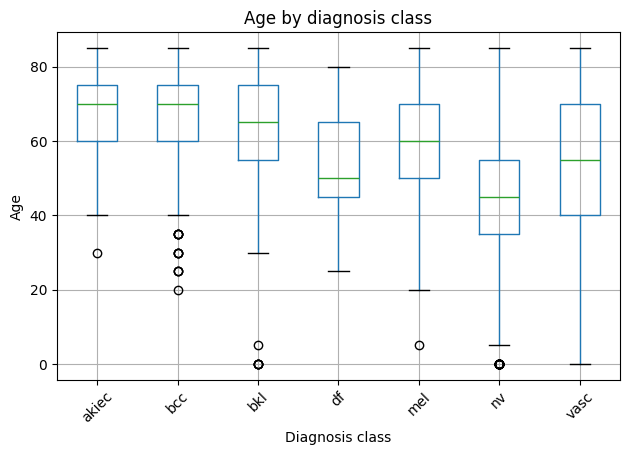

In [22]:
if "age" in df_available.columns:
    age_by_class = df_available.groupby("dx")["age"].describe()
    display(age_by_class)

    plt.figure(figsize=(8, 5))
    df_available.boxplot(column="age", by="dx")
    plt.xlabel("Diagnosis class")
    plt.ylabel("Age")
    plt.title("Age by diagnosis class")
    plt.suptitle("")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 10. Optional: create a cleaned metadata file

This saves a small CSV with absolute image paths and only rows with available images.


In [23]:
cleaned_path = DATA_DIR / "ham10000_metadata_with_paths.csv"
df_available.to_csv(cleaned_path, index=False)
print("Saved:", cleaned_path.resolve())

Saved: /Users/nikos/Documents/Master/Thesis/Software/Multimodal_CP/ham10000_metadata_with_paths.csv


## Next step

After this inspection, you can build a model like:

```text
image encoder + metadata encoder
        ↓
fusion layer
        ↓
classification head: dx
regression head: age
```

Recommended split:

```text
GroupShuffleSplit using lesion_id
```

so the same lesion does not appear in both train and test.
